# Caracterización de los grupos: perfil de movilidad y perfil temporal

Compara dos grupos según su movilidad y sus horarios. Aviso para leer este cuaderno: el perfil
de movilidad (sección 1) resulta estar afectado por la cobertura y no es informativo; el perfil
temporal (sección 2) es el que se sostiene. Los dos grupos:

- validador: usuarios confirmados como validadores (coinciden con su tarjeta Bip varios días).
- no-validador probable: usuarios que se mueven como pasajeros de transporte pero sin
  validación consistente (grupo transit_sin_match con patrón similar a validador).

La comparación es interna entre grupos, no entre comunas.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = ROOT / 'data'
feat = pd.read_parquet(DATA / 'features_clasificados.parquet')

feat['clase'] = np.where(feat['grupo']=='validador_consistente', 'validador',
                np.where((feat['grupo']=='transit_sin_match') & (feat['patron_similar']==True),
                         'no-validador probable', None))
g = feat[feat['clase'].notna()]
print(g['clase'].value_counts().to_string())

clase
no-validador probable    3541
validador                1852


## 1. Perfil de movilidad

Cómo se mueve cada grupo, según las variables del clasificador.

In [2]:
perfil = g.groupby('clase').agg(
    usuarios=('user_id','size'),
    paraderos_distintos=('n_paraderos_distintos','median'),
    frac_cerca_paradero=('frac_cerca_paradero','mean'),
    dias_activos=('n_dias_activos','median'),
    frac_manana=('frac_manana','mean'),
    frac_tarde=('frac_tarde','mean'),
).round(3)
print(perfil.to_string())

                       usuarios  paraderos_distintos  frac_cerca_paradero  dias_activos  frac_manana  frac_tarde
clase                                                                                                           
no-validador probable      3541                118.0                0.772          28.0        0.309       0.255
validador                  1852                150.0                0.860          29.0        0.342       0.239


Estas diferencias no son un resultado de conducta. El grupo validador se define por
tener coincidencias en varios días, así que por construcción tiene más pings y más cobertura
CDR. Por eso usa más paraderos distintos, aparece más días y anda más cerca de paraderos: es
consecuencia de tener más datos, no de moverse distinto. El perfil de movilidad, entonces, no
aporta información útil; la parte que sí se sostiene es la temporal (sección 2), porque las
fracciones por hora no dependen de cuántos pings tenga cada usuario.

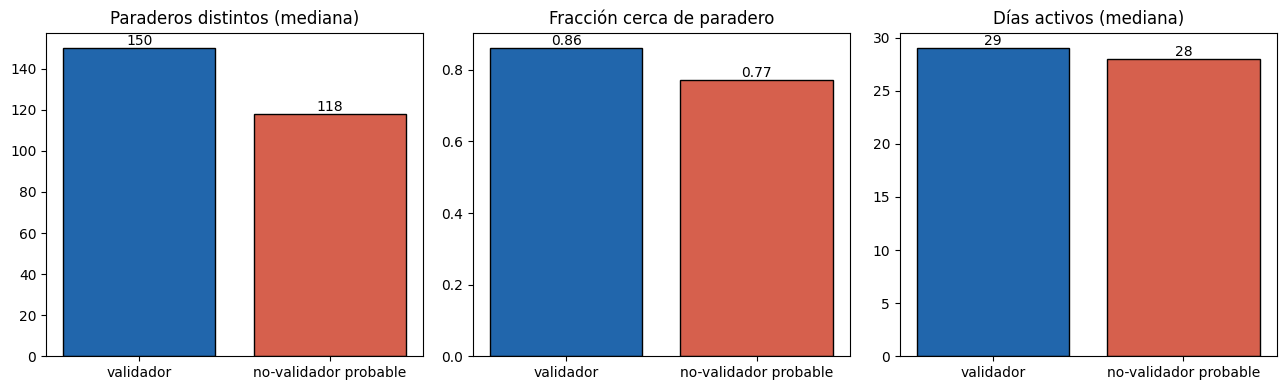

In [3]:
orden = ['validador', 'no-validador probable']
metricas = ['paraderos_distintos', 'frac_cerca_paradero', 'dias_activos']
titulos  = ['Paraderos distintos (mediana)', 'Fracción cerca de paradero', 'Días activos (mediana)']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, m, t in zip(axes, metricas, titulos):
    vals = [perfil.loc[c, m] for c in orden]
    ax.bar(orden, vals, color=['#2166ac', '#d6604d'], edgecolor='k')
    ax.set_title(t)
    for i, v in enumerate(vals):
        ax.text(i, v, f'{v:.2f}' if v < 5 else f'{v:.0f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

## 2. Perfil temporal

A qué hora del día se concentra la actividad de cada grupo. La actividad se mide con los pings
del CDR, que para usuarios con patrón de transporte aproxima sus horarios de desplazamiento.
La distribución está normalizada dentro de cada grupo, así que no depende de cuántos pings
tenga el grupo en total.

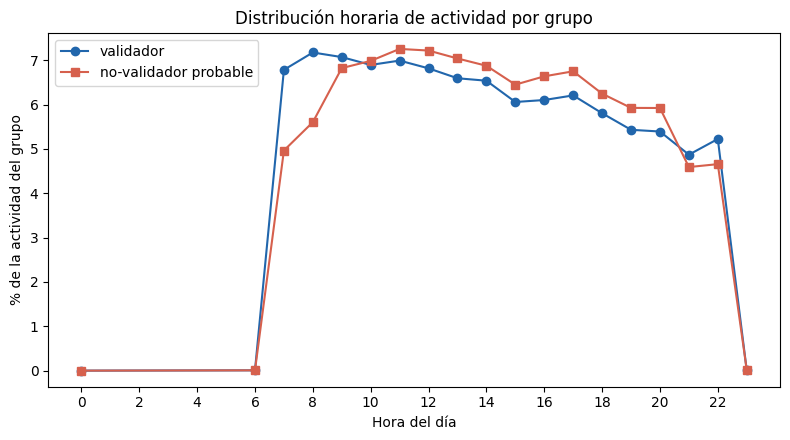

Hora de mayor actividad: validador 8:00   |   no-validador probable: 11:00
Mañana (6-11h):  validador 35%   no-validador 32%
Tarde (17-21h):  validador 28%   no-validador 29%


In [4]:
dh = pd.read_parquet(DATA / 'temporal' / 'dist_hora.parquet')
piv = dh.pivot(index='hora', columns='clase', values='frac').fillna(0)
piv = piv.rename(columns={'no_valida_probable':'no-validador probable'})

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(piv.index, piv['validador']*100, marker='o', color='#2166ac', label='validador')
ax.plot(piv.index, piv['no-validador probable']*100, marker='s', color='#d6604d', label='no-validador probable')
ax.set_xlabel('Hora del día'); ax.set_ylabel('% de la actividad del grupo')
ax.set_xticks(range(0,24,2)); ax.legend()
ax.set_title('Distribución horaria de actividad por grupo')
plt.tight_layout(); plt.show()

pico_v = piv['validador'].idxmax(); pico_n = piv['no-validador probable'].idxmax()
print(f'Hora de mayor actividad: validador {pico_v}:00   |   no-validador probable: {pico_n}:00')
print(f"Mañana (6-11h):  validador {piv.loc[6:11,'validador'].sum()*100:.0f}%   no-validador {piv.loc[6:11,'no-validador probable'].sum()*100:.0f}%")
print(f"Tarde (17-21h):  validador {piv.loc[17:21,'validador'].sum()*100:.0f}%   no-validador {piv.loc[17:21,'no-validador probable'].sum()*100:.0f}%")

El validador concentra su actividad en la mañana, alrededor de las 8h, como un viaje
habitual al trabajo. El no-validador probable se mueve más tarde (alrededor de las 11h) y de
forma más repartida durante el día. La diferencia es moderada pero consistente con un
comportamiento de viaje menos regular.

### Actividad por hora y día de la semana

Mismo dato, abierto por hora (filas) y día de la semana (columnas). El color es el promedio de
pings por usuario en esa hora y día.

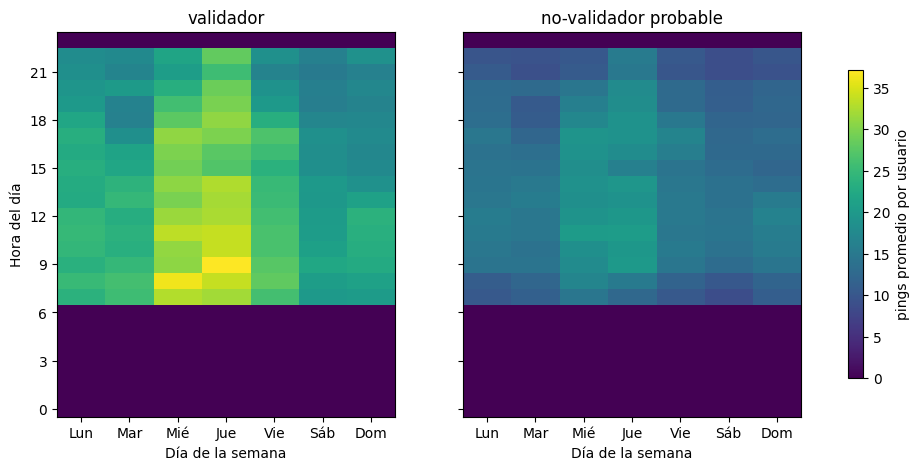

In [5]:
dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
hm_v = pd.read_parquet(DATA / 'temporal' / 'heatmap_validador.parquet')
hm_n = pd.read_parquet(DATA / 'temporal' / 'heatmap_no_valida_probable.parquet')
vmax = max(hm_v.values.max(), hm_n.values.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, hm, t in zip(axes, [hm_v, hm_n], ['validador', 'no-validador probable']):
    im = ax.imshow(hm.values, aspect='auto', origin='lower', cmap='viridis', vmin=0, vmax=vmax)
    ax.set_title(t); ax.set_xlabel('Día de la semana')
    ax.set_xticks(range(7)); ax.set_xticklabels(dias)
    ax.set_yticks(range(0,24,3)); ax.set_yticklabels(range(0,24,3))
axes[0].set_ylabel('Hora del día')
fig.colorbar(im, ax=axes, label='pings promedio por usuario', shrink=0.8)
plt.show()

## 3. Qué aporta esta caracterización

Hay que separar las dos partes:

- El perfil de movilidad (sección 1) no aporta: sus diferencias vienen de que el grupo
  validador tiene más cobertura CDR por construcción, no de un comportamiento distinto.
- El perfil temporal (sección 2) sí aporta, de forma modesta: el validador concentra su
  actividad en la mañana (alrededor de las 8h, como un viaje al trabajo), mientras que el no-validador
  probable tiene un perfil más tardío y repartido. Las fracciones por hora no dependen de la
  cantidad de pings, así que esta diferencia no es un artefacto de cobertura.

En resumen, de esta caracterización lo único que se sostiene es la diferencia temporal, como
descripción modesta y no como una medición de la conducta de evasión.